# Sales Analytics Dashboard & Forecasting

This notebook analyzes company sales data to build a business dashboard and forecast future sales trends.

## Objectives
- Analyze historical sales performance
- Identify top-performing products and regions
- Monitor key sales KPIs
- Build dashboard-style visualizations
- Forecast future sales using time series models

## Tools Used
- Python
- Pandas
- Matplotlib / Seaborn
- Plotly
- Scikit-learn / Statsmodels

## Business Problem

Understanding sales trends is critical for strategic planning. This project analyzes historical sales data to identify performance patterns and predict future revenue.

Key business questions:
1. What are the overall sales trends?
2. Which products and regions generate the most revenue?
3. How do sales change over time?
4. Can we forecast future sales to support planning?

## Dataset Overview

The dataset contains transaction-level sales data. There are 3 tables

### Daily Sales Data per item

| Column | Description |
|------|-------------|
| Item | Name of item |
| Sales Rank  Quantity (Lunch / Dinner) | Rank of Quantity Sold |
| Sales Rank Amount (Lunch / Dinner) | Rank of Sales Amount |
| Sales Summary (Cash / PayNow) | Monetary Value of daily sales |


### Daily Sales Data per hour

| Column | Description |
|------|-------------|
| Time (per hour) | Starting time of the hour |
| Orders | Number of orders |
| Amount | Monetary Value of hourly sales |

### Monthly Sales Data

| Column | Description |
|------|-------------|
| Month/Year | Month and year |
| Rent | Cost of rent |
| Salary | Cost of employee salaries |
| CPF/Levy | Cost of employee CPF |
| Supplier | Cost of supplier |
| Utilities | Cost of utilities |
| Season Parking | Cost for parking |
| Total Sales | Business revenue |
| Profit/Loss | Net Profit or Loss |

Source: Koryori Hayashi

## Import Libraries

We import the required Python libraries for data processing, visualization, and forecasting.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')


## Load Dataset

The sales dataset is loaded into a Pandas DataFrame for analysis.

In [2]:
def find_data_xlsx() -> Path:
    candidates = [
        Path('data.xlsx'),
        Path('data') / 'data.xlsx',
        Path('..') / 'data' / 'data.xlsx',  
        Path('Dashboard') / 'data' / 'data.xlsx',
        Path('..') / 'Dashboard' / 'data' / 'data.xlsx',
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError('Could not find Dashboard/data/data.xlsx. Check your working directory.')


XLSX_PATH = find_data_xlsx()
XLSX_PATH


WindowsPath('C:/Users/65967/OneDrive - Singapore Management University/Documents/GitHub/Koryori_Hayashi/Dashboard/data/data.xlsx')

In [3]:
# Read the whole sheet as a raw grid (the 3 tables live side-by-side in the same sheet)
raw = pd.read_excel(XLSX_PATH, sheet_name=0, header=None)
raw.shape


(79, 20)

In [4]:
HEADER_ROW = 4  # row 5 in Excel (0-based index)

# Table 1: Daily Sales per item (A:D)
items = raw.iloc[HEADER_ROW:, 0:4].copy()
items.columns = raw.iloc[HEADER_ROW, 0:4].tolist()
items = items.iloc[1:].reset_index(drop=True)
items = items.dropna(subset=[items.columns[0]])

# Table 2: Daily Sales per hour (F:H)
hourly = raw.iloc[HEADER_ROW:, 5:8].copy()
hourly.columns = raw.iloc[HEADER_ROW, 5:8].tolist()
hourly = hourly.iloc[1:].reset_index(drop=True)
hourly = hourly.dropna(subset=[hourly.columns[0]])

# Table 3: Monthly Sales Data (J:R)
monthly = raw.iloc[HEADER_ROW:, 9:18].copy()
monthly.columns = raw.iloc[HEADER_ROW, 9:18].tolist()
monthly = monthly.iloc[1:].reset_index(drop=True)
monthly = monthly.dropna(subset=[monthly.columns[0]])

items.head(), hourly.head(), monthly.head()


(                        Item Sales Rank  Quantity (Lunch / Dinner) Sales Rank Amount (Lunch / Dinner)  \
 0         Chicken Nanban Don                                     1                                  2   
 1         Pork Shogayaki Don                                     2                                  1   
 2        Salmon Teriyaki Don                                     3                                  3   
 3  Salmon Belly Teriyaki Don                                     4                                  4   
 4       Chicken Teriyaki Don                                     5                                  5   
 
   Sales Summary (Cash / PayNow)  
 0                           420  
 1                           450  
 2                           400  
 3                           380  
 4                           360  ,
   Time (per hour) Orders  Amount
 0        11:00:00     12  149.27
 1        12:00:00     11  138.33
 2        13:00:00     11  146.28
 3        14:00

In [8]:
# Clean column names
monthly.columns = monthly.columns.str.strip()
hourly.columns = hourly.columns.str.strip()
items.columns = items.columns.str.strip()


## Feature Engineering

Additional features are created to support analysis and forecasting.

New variables include:
- Year
- Month
- Quarter
- Year-Month for time series analysis

In [9]:
# Some Excel exports label this column as 'Month / Year'. Normalize it.

monthly['Month'] = pd.to_datetime(monthly["Month / Year"], errors='coerce')
monthly = monthly.sort_values('Month').reset_index(drop=True)

monthly['Year'] = monthly['Month'].dt.year
monthly['MonthNum'] = monthly['Month'].dt.month
monthly['Quarter'] = monthly['Month'].dt.to_period('Q').astype(str)
monthly['YearMonth'] = monthly['Month'].dt.to_period('M').astype(str)

monthly[['Month', 'YearMonth', 'Year','MonthNum','Quarter','Total Sales', 'Profit / Loss']].head()


,Month,YearMonth,Year,MonthNum,Quarter,Total Sales,Profit / Loss
0,2025-01-01,2025-01,2025,1,2025Q1,3404.0,111.60
1,2025-02-01,2025-02,2025,2,2025Q1,2173.6,88.64
2,2025-03-01,2025-03,2025,3,2025Q1,3313.8,225.25
3,2025-04-01,2025-04,2025,4,2025Q2,1843.0,235.54
4,2025-05-01,2025-05,2025,5,2025Q2,1812.8,50.89


## Key Performance Indicators (KPIs)

Important metrics used to evaluate business performance:

- Total Revenue
- Total Orders
- Total Profit
- Average Order Value
- Total Units Sold

In [ ]:
# Convert numeric columns to numeric types, coercing errors to NaN
for col in ['Total Sales', 'Profit / Loss']:
    if col in monthly.columns:
        monthly[col] = pd.to_numeric(monthly[col], errors='coerce')

for col in ['Orders', 'Amount']:
    if col in hourly.columns:
        hourly[col] = pd.to_numeric(hourly[col], errors='coerce')

if 'Sales Summary (Cash / PayNow)' in items.columns:
    items['Sales Summary (Cash / PayNow)'] = pd.to_numeric(
        items['Sales Summary (Cash / PayNow)'], errors='coerce'
    )

# Parse and sort monthly dates
monthly['Month'] = pd.to_datetime(monthly['Month / Year'], errors='coerce')
monthly = monthly.sort_values('Month').reset_index(drop=True)

monthly['Year'] = monthly['Month'].dt.year
monthly['MonthNum'] = monthly['Month'].dt.month
monthly['Quarter'] = monthly['Month'].dt.to_period('Q').astype(str)
monthly['YearMonth'] = monthly['Month'].dt.to_period('M').astype(str)

#Extract hour safely
hourly['Hour'] = hourly['Time (per hour)'].astype(str).str[:2]
hourly['Hour'] = pd.to_numeric(hourly['Hour'], errors='coerce')

#KPI calculations
total_sales_latest_month = (
    float(monthly['Total Sales'].iloc[-1])
    if len(monthly) and monthly['Total Sales'].notna().any()
    else 0.0
)

profit_latest_month = (
    float(monthly['Profit / Loss'].iloc[-1])
    if len(monthly) and monthly['Profit / Loss'].notna().any()
    else 0.0
)

margin_latest_month_pct = (
    profit_latest_month / total_sales_latest_month * 100
    if total_sales_latest_month
    else 0.0
)

total_orders_day = int(hourly['Orders'].sum()) if len(hourly) else 0
total_revenue_day = float(hourly['Amount'].sum()) if len(hourly) else 0.0
avg_order_value = total_revenue_day / total_orders_day if total_orders_day else 0.0

total_daily_item_sales = (
    float(items['Sales Summary (Cash / PayNow)'].sum())
    if len(items) and 'Sales Summary (Cash / PayNow)' in items.columns
    else 0.0
)

valid_hourly = hourly.dropna(subset=['Amount', 'Hour'])
peak_hour = (
    int(valid_hourly.loc[valid_hourly['Amount'].idxmax(), 'Hour'])
    if len(valid_hourly)
    else None
)

top_selling_item = (
    items.loc[items['Sales Summary (Cash / PayNow)'].idxmax(), 'Item']
    if len(items) and 'Sales Summary (Cash / PayNow)' in items.columns and items['Sales Summary (Cash / PayNow)'].notna().any()
    else None
)

top_item_sales = (
    float(items['Sales Summary (Cash / PayNow)'].max())
    if len(items) and 'Sales Summary (Cash / PayNow)' in items.columns
    else 0.0
)

# KPI output

kpis = {
    'Total Sales (Latest Month)': round(total_sales_latest_month, 2),
    'Profit/Loss (Latest Month)': round(profit_latest_month, 2),
    'Margin % (Latest Month)': round(margin_latest_month_pct, 2),
    'Orders (Today)': total_orders_day,
    'Revenue (Today)': round(total_revenue_day, 2),
    'Average Order Value': round(avg_order_value, 2),
    'Daily Sales Total (Items)': round(total_daily_item_sales, 2),
    'Peak Hour': f"{peak_hour}:00" if peak_hour is not None else None,
    'Top Selling Item': top_selling_item,
    'Top Item Sales': round(top_item_sales, 2),
}

kpi_series = pd.Series(kpis)
print(kpi_series)


Total Sales (Latest Month)                2544.4
Profit/Loss (Latest Month)                131.36
Margin % (Latest Month)                     5.16
Orders (Daily)                                73
Revenue (Daily)                           985.11
Average Order Value                        13.49
Daily Sales Total (Items)                 8013.0
Peak Hour                                  11:00
Top Selling Item              Pork Shogayaki Don
Top Item Sales                             450.0
dtype: object


## Exploratory Data Analysis

EDA helps understand patterns, distributions, and relationships within the sales data.

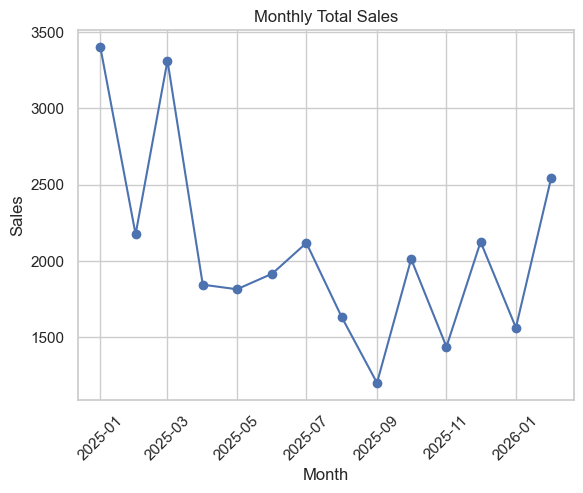

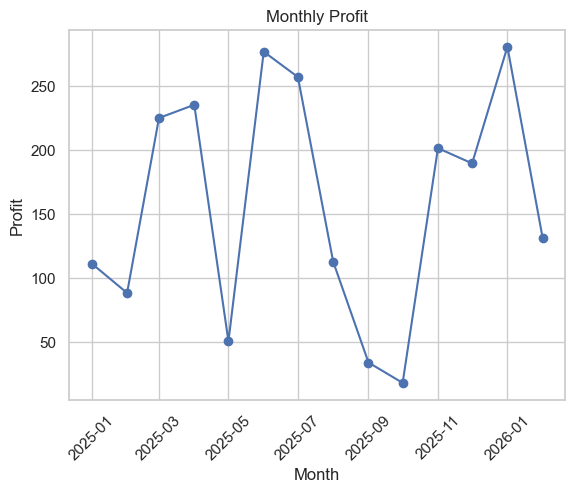

In [17]:
# Monthly Trends (Revenue & Profit

plt.figure()
plt.plot(monthly['Month'], monthly['Total Sales'], marker='o')
plt.title("Monthly Total Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

plt.figure()
plt.plot(monthly['Month'], monthly['Profit / Loss'], marker='o')
plt.title("Monthly Profit")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

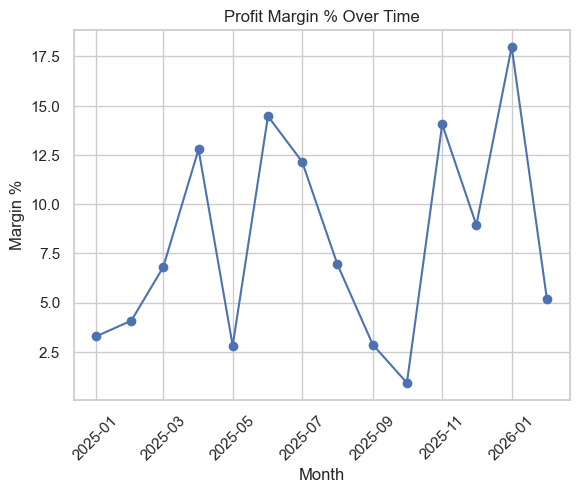

In [18]:
# Profit Margin Trend
monthly['Margin %'] = (monthly['Profit / Loss'] / monthly['Total Sales']) * 100

plt.figure()
plt.plot(monthly['Month'], monthly['Margin %'], marker='o')
plt.title("Profit Margin % Over Time")
plt.xlabel("Month")
plt.ylabel("Margin %")
plt.xticks(rotation=45)
plt.show()

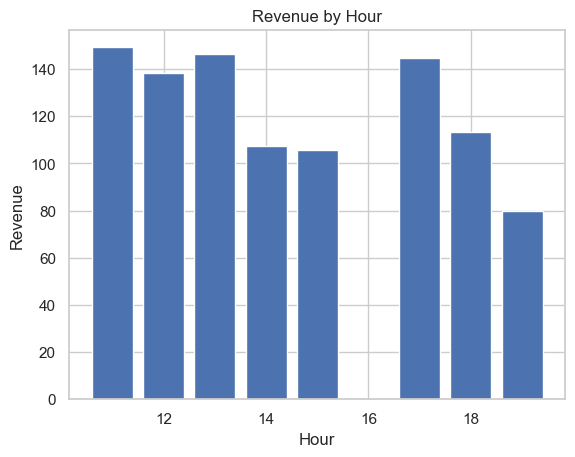

In [19]:
# Hourly Trends
plt.figure()
plt.bar(hourly['Hour'], hourly['Amount'])
plt.title("Revenue by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.show()

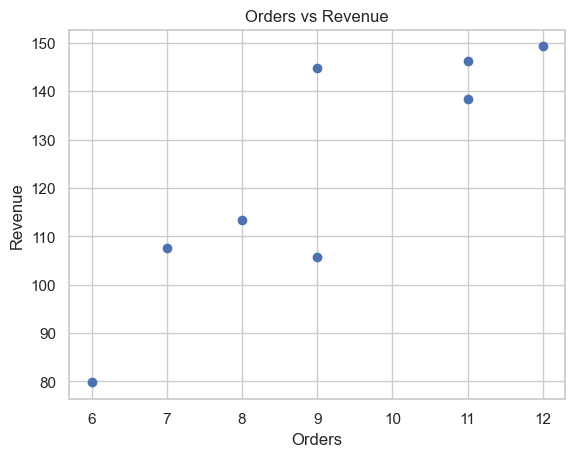

In [ ]:
# Number of Orders vs Total Revenue
plt.figure()
plt.scatter(hourly['Orders'], hourly['Amount'])
plt.title("Orders vs Revenue")
plt.xlabel("Orders")
plt.ylabel("Revenue")
plt.show()

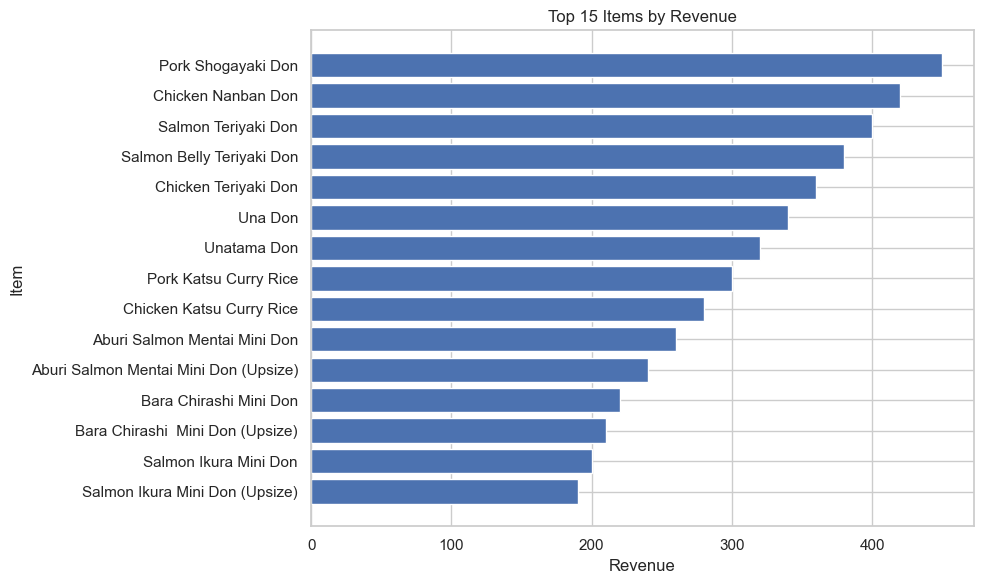

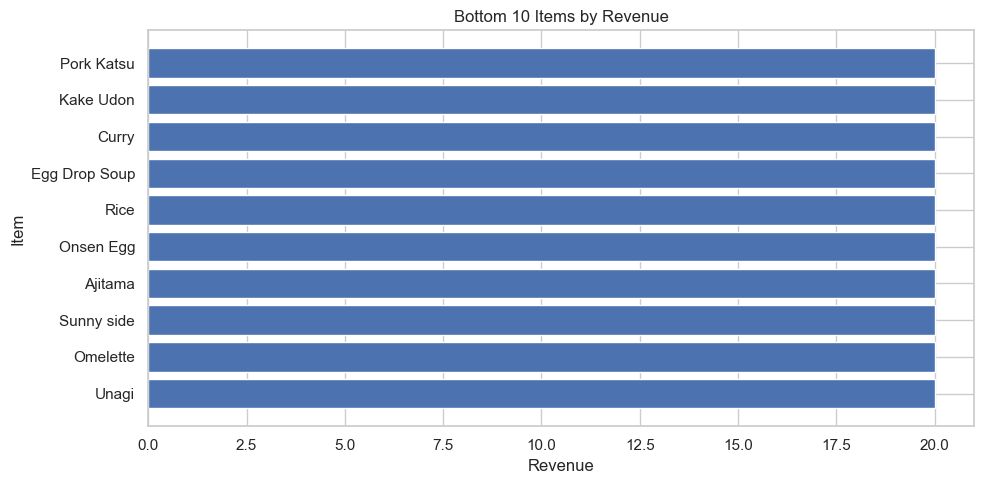

In [30]:
# Item Performance
top_n = 15

items_sorted = items.sort_values('Sales Summary (Cash / PayNow)', ascending=False).head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(items_sorted['Item'], items_sorted['Sales Summary (Cash / PayNow)'])
plt.title(f"Top {top_n} Items by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Item")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

bottom_n = 10

items_bottom = items.sort_values('Sales Summary (Cash / PayNow)', ascending=True).head(bottom_n)

plt.figure(figsize=(10, 5))
plt.barh(items_bottom['Item'], items_bottom['Sales Summary (Cash / PayNow)'])
plt.title(f"Bottom {bottom_n} Items by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Item")
plt.tight_layout()
plt.show()

In [28]:
# Top vs Bottom Items
top_5 = items_sorted.head(5)
bottom_5 = items_sorted.tail(5)

print("Top 5 Items:\n", top_5[['Item', 'Sales Summary (Cash / PayNow)']])
print("\nBottom 5 Items:\n", bottom_5[['Item', 'Sales Summary (Cash / PayNow)']])

Top 5 Items:
                         Item  Sales Summary (Cash / PayNow)
1         Pork Shogayaki Don                            450
0         Chicken Nanban Don                            420
2        Salmon Teriyaki Don                            400
3  Salmon Belly Teriyaki Don                            380
4       Chicken Teriyaki Don                            360

Bottom 5 Items:
                                      Item  Sales Summary (Cash / PayNow)
10  Aburi Salmon Mentai Mini Don (Upsize)                            240
11                 Bara Chirashi Mini Don                            220
12       Bara Chirashi  Mini Don (Upsize)                            210
13                  Salmon Ikura Mini Don                            200
14         Salmon Ikura Mini Don (Upsize)                            190


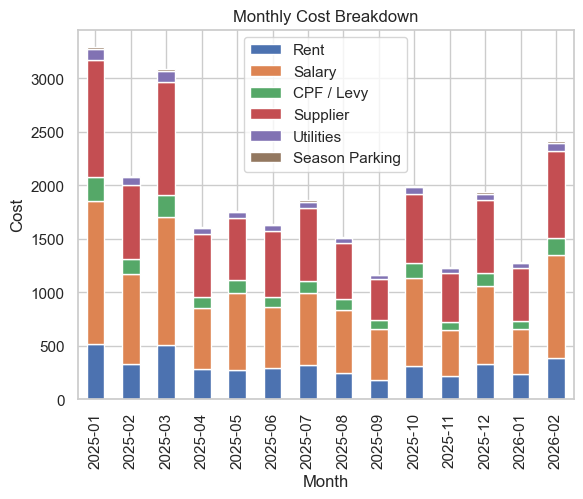

In [26]:
# Monthly Cost Breakdown
cost_cols = ['Rent', 'Salary', 'CPF / Levy', 'Supplier', 'Utilities', 'Season Parking']
monthly.set_index('YearMonth')[cost_cols].plot(kind='bar', stacked=True)

plt.title("Monthly Cost Breakdown")
plt.xlabel("Month")
plt.ylabel("Cost")
plt.show()

In [25]:
# Correlation Analysis
corr = monthly[['Total Sales', 'Profit / Loss'] + cost_cols].corr()
print(corr)

                Total Sales  Profit / Loss      Rent    Salary  CPF / Levy  Supplier  Utilities  Season Parking
Total Sales        1.000000       0.059601  1.000000  0.960301    0.960306  1.000000   0.996930        1.000000
Profit / Loss      0.059601       1.000000  0.059600 -0.221236   -0.221219  0.059599  -0.018745        0.059741
Rent               1.000000       0.059600  1.000000  0.960301    0.960306  1.000000   0.996930        1.000000
Salary             0.960301      -0.221236  0.960301  1.000000    1.000000  0.960301   0.979196        0.960261
CPF / Levy         0.960306      -0.221219  0.960306  1.000000    1.000000  0.960306   0.979200        0.960266
Supplier           1.000000       0.059599  1.000000  0.960301    0.960306  1.000000   0.996930        1.000000
Utilities          0.996930      -0.018745  0.996930  0.979196    0.979200  0.996930   1.000000        0.996918
Season Parking     1.000000       0.059741  1.000000  0.960261    0.960266  1.000000   0.996918        1

## Preparing Data for Forecasting

To forecast sales, the dataset is aggregated into monthly revenue values.

Time series forecasting requires:
- chronological order
- evenly spaced time intervals

## Sales Forecasting

Forecasting helps predict future revenue trends based on historical data.

Methods that can be used:
- Linear Regression
- ARIMA
- Prophet
- Exponential Smoothing

## Scenario Simulation & Future Planning

Beyond forecasting future sales based on historical data, scenario simulations allow us to test how different business strategies might impact future revenue.

These simulations help answer questions such as:

- What if marketing increases sales volume?
- What if prices increase?
- What if demand drops due to market conditions?

The following scenarios model potential business outcomes.

### Scenario 1: Marketing Campaign Impact

Assumption:
- A marketing campaign increases sales volume by 10%.

Objective:
Estimate the potential revenue increase if marketing improves product visibility and demand.

Expected Outcome:
Higher monthly sales compared to the baseline forecast.

### Scenario 2: Price Increase Strategy

Assumption:
- Product prices increase by 5%.

Objective:
Estimate how a moderate price increase affects revenue.

Risk Consideration:
Price increases may reduce demand, so this scenario assumes demand remains constant.

### Scenario 3: Market Slowdown

Assumption:
- Market demand decreases by 8%.

Objective:
Evaluate how economic downturns or market changes might impact revenue.

This helps businesses prepare contingency plans.

## Scenario Comparison

The following comparison shows projected revenue under different business strategies:

- Baseline forecast
- Marketing campaign scenario
- Price increase scenario
- Demand decline scenario

This analysis helps identify which strategies generate the highest potential revenue.

### Monte Carlo Simulation 

Monte Carlo simulation generates thousands of possible sales outcomes by randomly varying demand within a specified range.

This approach helps estimate:

- Best case revenue
- Worst case revenue
- Expected revenue range